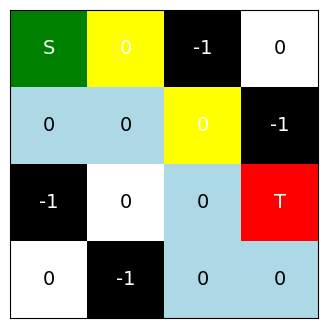

Bidirectional Search Path from S to T: [(0, 0), (0, 1), (1, 2), (2, 3)]


In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from collections import deque
from matplotlib.colors import ListedColormap
from IPython.display import clear_output
import heapq
import time

# Grid definition
grid = [
    ["S", "0", "-1", "0"],
    ["0", "0", "0", "-1"],
    ["-1", "0", "0", "T"],
    ["0", "-1", "0", "0"]
]

rows, cols = len(grid), len(grid[0])

# Find start and target positions
for i in range(rows):
    for j in range(cols):
        if grid[i][j] == "S":
            start = (i, j)
        if grid[i][j] == "T":
            target = (i, j)

# Directions: 8 directions (up, down, left, right, diagonals)
directions = [(-1,0),(0,1),(1,0),(1,1),(0,-1),(-1,-1),(1,-1),(-1,1)]

# Display function
def display_grid(grid, visited=set(), frontier=set(), path=[]):
    cmap = ListedColormap(['white','black','green','red','lightblue','orange','yellow'])
    color_grid = np.zeros((rows, cols))
    
    for i in range(rows):
        for j in range(cols):
            cell = grid[i][j]
            if cell == "-1":
                color_grid[i,j] = 1
            elif cell == "S":
                color_grid[i,j] = 2
            elif cell == "T":
                color_grid[i,j] = 3
            elif (i,j) in path:
                color_grid[i,j] = 6
            elif (i,j) in frontier:
                color_grid[i,j] = 5
            elif (i,j) in visited:
                color_grid[i,j] = 4
            else:
                color_grid[i,j] = 0
    
    clear_output(wait=True)
    plt.figure(figsize=(cols, rows))
    plt.imshow(color_grid, cmap=cmap)
    
    for i in range(rows):
        for j in range(cols):
            plt.text(j, i, grid[i][j], ha="center", va="center",
                     color="white" if color_grid[i,j] in [1,2,3,5,6] else "black", fontsize=14)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    time.sleep(0.3)

# Menu
print("Select Algorithm:")
print("1 - BFS")
print("2 - DFS")
print("3 - UCS (Uniform-Cost Search)")
print("4 - DLS (Depth-Limited Search)")
print("5 - IDDFS (Iterative Deepening DFS)")
print("6 - Bidirectional Search")
choice = input("Enter choice (1, 2, 3, 4, 5, or 6): ")

if choice not in ["1","2","3","4","5","6"]:
    print("Invalid choice. Defaulting to BFS.")
    choice = "1"

# ------------------- BFS -------------------
if choice == "1":
    algorithm = "BFS"
    queue = deque([start])
    visited = set([start])
    parent = {start: None}
    found = False

    while queue:
        current = queue.popleft()
        if current == target:
            found = True
            break
        visited.add(current)
        frontier = set(queue)
        display_grid(grid, visited, frontier)
        
        for dx, dy in directions:
            ni, nj = current[0]+dx, current[1]+dy
            if 0<=ni<rows and 0<=nj<cols and grid[ni][nj]!="-1" and (ni,nj) not in visited and (ni,nj) not in queue:
                queue.append((ni,nj))
                parent[(ni,nj)] = current

# ------------------- DFS -------------------
elif choice == "2":
    algorithm = "DFS"
    stack = [start]
    visited = set([start])
    parent = {start: None}
    found = False

    while stack:
        current = stack.pop()
        if current == target:
            found = True
            break
        visited.add(current)
        frontier = set(stack)
        display_grid(grid, visited, frontier)
        
        for dx, dy in directions:
            ni, nj = current[0]+dx, current[1]+dy
            if 0<=ni<rows and 0<=nj<cols and grid[ni][nj]!="-1" and (ni,nj) not in visited and (ni,nj) not in stack:
                stack.append((ni,nj))
                parent[(ni,nj)] = current

# ------------------- UCS -------------------
elif choice == "3":
    algorithm = "UCS"
    pq = []
    heapq.heappush(pq, (0, start))
    visited = set()
    parent = {start: None}
    cost_so_far = {start: 0}
    found = False

    while pq:
        current_cost, current = heapq.heappop(pq)
        if current == target:
            found = True
            break
        if current in visited:
            continue
        visited.add(current)
        frontier = set([n for c,n in pq])
        display_grid(grid, visited, frontier)
        
        for dx, dy in directions:
            ni, nj = current[0]+dx, current[1]+dy
            if 0<=ni<rows and 0<=nj<cols and grid[ni][nj]!="-1":
                new_cost = current_cost + 1
                if (ni,nj) not in cost_so_far or new_cost < cost_so_far[(ni,nj)]:
                    cost_so_far[(ni,nj)] = new_cost
                    heapq.heappush(pq, (new_cost, (ni,nj)))
                    parent[(ni,nj)] = current

# ------------------- DLS -------------------
elif choice == "4":
    algorithm = "DLS"
    depth_limit = int(input("Enter depth limit for DLS: "))
    stack = [(start,0)]
    visited = set([start])
    parent = {start: None}
    found = False

    while stack:
        current, depth = stack.pop()
        if current == target:
            found = True
            break
        visited.add(current)
        frontier = set([n for n,d in stack])
        display_grid(grid, visited, frontier)
        
        if depth < depth_limit:
            for dx, dy in directions:
                ni, nj = current[0]+dx, current[1]+dy
                if 0<=ni<rows and 0<=nj<cols and grid[ni][nj]!="-1" and (ni,nj) not in visited and ((ni,nj), depth+1) not in stack:
                    stack.append(((ni,nj), depth+1))
                    parent[(ni,nj)] = current

# ------------------- IDDFS -------------------
elif choice == "5":
    algorithm = "IDDFS"
    found = False
    parent = {}

    def dls(node, depth, limit, visited):
        visited.add(node)
        display_grid(grid, visited, set())

        if node == target:
            return True

        if depth < limit:
            for dx, dy in directions:
                ni, nj = node[0]+dx, node[1]+dy
                if 0<=ni<rows and 0<=nj<cols and grid[ni][nj]!="-1" and (ni,nj) not in visited:
                    parent[(ni,nj)] = node
                    if dls((ni,nj), depth+1, limit, visited):
                        return True
        return False

    for limit in range(rows * cols):
        visited = set()
        parent = {start: None}
        if dls(start, 0, limit, visited):
            found = True
            break

# ------------------- Bidirectional Search -------------------
elif choice == "6":
    algorithm = "Bidirectional Search"

    q_start = deque([start])
    q_goal = deque([target])

    visited_start = {start}
    visited_goal = {target}

    parent_start = {start: None}
    parent_goal = {target: None}

    found = False
    meeting_node = None

    while q_start and q_goal and not found:
        for _ in range(len(q_start)):
            current = q_start.popleft()
            for dx, dy in directions:
                ni, nj = current[0] + dx, current[1] + dy
                neighbor = (ni, nj)
                if 0 <= ni < rows and 0 <= nj < cols and grid[ni][nj] != "-1":
                    if neighbor not in visited_start:
                        visited_start.add(neighbor)
                        parent_start[neighbor] = current
                        q_start.append(neighbor)
                        if neighbor in visited_goal:
                            meeting_node = neighbor
                            found = True
                            break
            if found:
                break
        if found:
            break

        for _ in range(len(q_goal)):
            current = q_goal.popleft()
            for dx, dy in directions:
                ni, nj = current[0] + dx, current[1] + dy
                neighbor = (ni, nj)
                if 0 <= ni < rows and 0 <= nj < cols and grid[ni][nj] != "-1":
                    if neighbor not in visited_goal:
                        visited_goal.add(neighbor)
                        parent_goal[neighbor] = current
                        q_goal.append(neighbor)
                        if neighbor in visited_start:
                            meeting_node = neighbor
                            found = True
                            break
            if found:
                break

        frontier = set(q_start) | set(q_goal)
        visited = visited_start | visited_goal
        display_grid(grid, visited, frontier)

# ------------------- PATH RECONSTRUCTION -------------------
if choice != "6":
    # For BFS, DFS, UCS, DLS, IDDFS
    if found:
        path = []
        node = target
        while node is not None:
            path.append(node)
            node = parent.get(node)
        path.reverse()
        display_grid(grid, visited, set(), path)
        print(f"{algorithm} Path from S to T:", path)
    else:
        display_grid(grid, visited)
        print(f"{algorithm} did not find a path")
else:
    # Bidirectional Path
    if found:
        path_start = []
        node = meeting_node
        while node is not None:
            path_start.append(node)
            node = parent_start[node]
        path_start.reverse()

        path_goal = []
        node = parent_goal[meeting_node]
        while node is not None:
            path_goal.append(node)
            node = parent_goal[node]

        path = path_start + path_goal
        display_grid(grid, visited_start | visited_goal, set(), path)
        print(f"{algorithm} Path from S to T:", path)
    else:
        display_grid(grid, visited_start | visited_goal)
        print(f"{algorithm} did not find a path")
